# Retrieval-Augmented Generation: How It Works


[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/code/addarm/rag-how-they-work)


![Banner](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/rag_how_they_work_banner.png)


## Introduction

A language model generates text by predicting the next token from everything that precedes it. That makes it powerful, but also unreliable whenever the answer depends on facts the model never saw during training, facts that changed since training, or facts locked inside a private corpus. The model will still produce fluent text, but it'll hallucinate.

**Retrieval-Augmented Generation (RAG)** addresses this by inserting a retrieval step before generation: given a user query, find the most relevant passages from an external knowledge base and inject them into the model's context. The model then conditions its output on retrieved evidence rather than relying solely on parametric memory.

This notebook builds a RAG system from scratch. We start with the embedding space that makes retrieval possible, develop chunking strategies that determine what gets indexed, build a vector store for similarity search, wire the full retrieve → augment → generate pipeline, evaluate its outputs, and extend the pattern with reranking, hybrid search, and agentic retrieval.

Every demo runs on **SmolLM2-135M** with CPU-only inference. No GPU or API keys are required.

This is **Part 4 of 4** in "The Road to Agency":

1. [How LLMs Work](llms_how_they_work.ipynb): architecture, training objective, and inference pipeline.
2. [Prompt Engineering](prompt_engineering_how_they_work.ipynb): prompt conditioning, in-context learning, chain-of-thought, and reasoning-time compute.
3. [How Agents Work](agents_how_they_work.ipynb): tool use, orchestration, memory, evaluation, and agentic loops.
4. **Retrieval-Augmented Generation** (this notebook): embeddings, vector search, chunking, RAG pipelines, evaluation, and agentic retrieval.


# Notebook Setup

We use the standard numerical stack plus **PyTorch** and **Hugging Face Transformers** to load
[SmolLM2-135M](https://huggingface.co/HuggingFaceTB/SmolLM2-135M). Additionally, we use
**scikit-learn** for TF-IDF and cosine similarity. All vector search is implemented in pure
NumPy: no external vector database is required, though we discuss FAISS and approximate
nearest neighbours in the theory sections.

> **Download note.** The first run downloads ~270 MB of model weights. All inference runs on CPU.


In [1]:
!pip install torch transformers numpy pandas matplotlib seaborn scikit-learn --quiet


In [2]:
import json, sys, math, warnings, platform, re, hashlib, textwrap
from collections import Counter
from dataclasses import dataclass, field
from typing import Optional, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers as _tf
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(42)
torch.manual_seed(42)

print(f"PyTorch {torch.__version__}  |  Transformers {_tf.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")


C:\Users\adamd\conda_envs\deeplearn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.11.0+cpu  |  Transformers 5.6.2
Device: cpu


## Loading SmolLM2-135M

We load the base model for text generation. For embeddings we will use the model's own hidden states: the same approach used in many practical systems that extract embeddings from a causal LM's last hidden layer.


In [3]:
BASE_ID = "HuggingFaceTB/SmolLM2-135M"
tokenizer = AutoTokenizer.from_pretrained(BASE_ID)
model = AutoModelForCausalLM.from_pretrained(
    BASE_ID, dtype=torch.float32, attn_implementation="eager"
)
model.eval()
print(f"Tokenizer vocab size: {tokenizer.vocab_size:,}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights:   6%|▋         | 17/272 [00:00<00:01, 169.05it/s]

Loading weights:  58%|█████▊    | 157/272 [00:00<00:00, 886.72it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 925.00it/s]

Tokenizer vocab size: 49,152
Model parameters: 134,515,008


# Part I: Embeddings for Retrieval

## Why Embeddings Matter for RAG

Retrieval-augmented generation needs a way to measure *semantic similarity* between a user's query and candidate passages. Keyword matching (BM25, TF-IDF) captures lexical overlap but misses paraphrases and synonyms. Dense embeddings map text into a continuous vector space where semantically related passages cluster together, enabling retrieval based on *meaning* rather than surface tokens.

**How it works.** Given text $x$, an embedding model $f$ produces a vector $\mathbf{v} = f(x) \in \mathbb{R}^d$. Similarity is measured via cosine similarity:

$$
\text{sim}(q, p) = \frac{\mathbf{v}_q \cdot \mathbf{v}_p}{\|\mathbf{v}_q\| \, \|\mathbf{v}_p\|}
$$

The numerator is a dot product; the denominator turns it into an angle-only quantity, so two passages that talk about the same thing land on the same direction in $\mathbb{R}^d$ regardless of length.

**Dedicated embedding models vs causal LMs.** Production systems typically use bidirectional encoders (BERT-family, E5, GTE, Nomic, BGE) trained specifically for retrieval with contrastive objectives (positive query-passage pairs are pulled together, hard negatives pushed apart). A causal LM like SmolLM2 can also produce useful embeddings from its last hidden states, but two structural facts make those embeddings weaker for retrieval. First, causal attention is one-sided: a token at position $t$ never sees positions $> t$, so the pooled representation is biased toward later tokens. Second, the model was trained for next-token prediction, not for placing semantically similar passages near each other in vector space. The result is workable for didactic purposes but several points behind dedicated retrievers on standard benchmarks like MTEB. We use SmolLM2 here for consistency with the series; the API is identical, so swapping in a real encoder is one line.

### Families of Retriever Models

| Family | Example | What it produces | Cost per pair | When to use |
|--------|---------|------------------|---------------|-------------|
| **Causal-LM mean-pooled** | SmolLM2, Llama mean-pool | one vector per text | one forward pass | didactic, cold start |
| **Bi-encoder (dense)** | E5, BGE, GTE, Nomic, voyage-3 | one vector per text | one forward pass per text | most production retrieval |
| **Cross-encoder** | BGE-reranker, Cohere rerank-3 | one score per (q, p) pair | one forward pass *per pair* | reranking the top-$K$ |
| **Multi-vector (late interaction)** | ColBERTv2, BGE-M3 | one vector per token | quadratic-in-tokens but cacheable | high-recall retrieval at scale |

Bi-encoders dominate first-stage retrieval because the passage vectors can be precomputed and stored. Cross-encoders are accurate but cannot precompute (they need both inputs at the same time), so they only run on the small candidate set produced by the first stage. Multi-vector models like ColBERTv2 (Santhanam et al., 2022) sit in between: they keep one vector per token and score with a *late interaction* operator (max-similarity per query token, summed), which gives much of the cross-encoder's quality while still allowing per-passage caching. BGE-M3 (Chen et al., 2024) goes further and exposes dense, sparse, and multi-vector representations from one model.

**Engineer lens.** Embedding dimensionality determines storage cost and search speed. Common dimensions: 384 (MiniLM, BGE-small), 768 (BERT-base, BGE-base, E5-base), 1024 (BGE-large, E5-large, voyage-3), 576 (SmolLM2). One million passages at $d=1024$ in float32 is 4 GB before any index overhead. Normalising vectors to unit length lets cosine similarity reduce to a dot product, which is what FAISS `IndexFlatIP` actually computes.

**Failure mode.** Embedding models have a training distribution. Out-of-domain queries (code queries against a prose index, multilingual queries against an English-only encoder) degrade retrieval quality silently. The cosine scores still look reasonable, but the retrieved passages are irrelevant. Always sanity-check on held-out in-domain pairs before trusting a new encoder.


### Demo 1: Extracting Embeddings from SmolLM2

We extract embeddings by running text through the model and mean-pooling the last hidden
states. This is a standard approach for deriving sentence embeddings from causal LMs.


Query: 'How does attention work in transformers?'

Rank     Score  Passage
--------------------------------------------------------------------------------
1       0.8634  ✓ Self-attention allows each token to attend to every other token simult
2       0.7975  ✓ Recurrent neural networks process tokens sequentially, creating a bott
3       0.7568  ✓ The transformer architecture uses self-attention to process sequences 
4       0.7495    Attention mechanisms compute weighted sums of value vectors based on q
5       0.7329    The stock market closed higher on Tuesday following strong earnings re
6       0.6517    The weather forecast predicts rain for the weekend across the eastern 


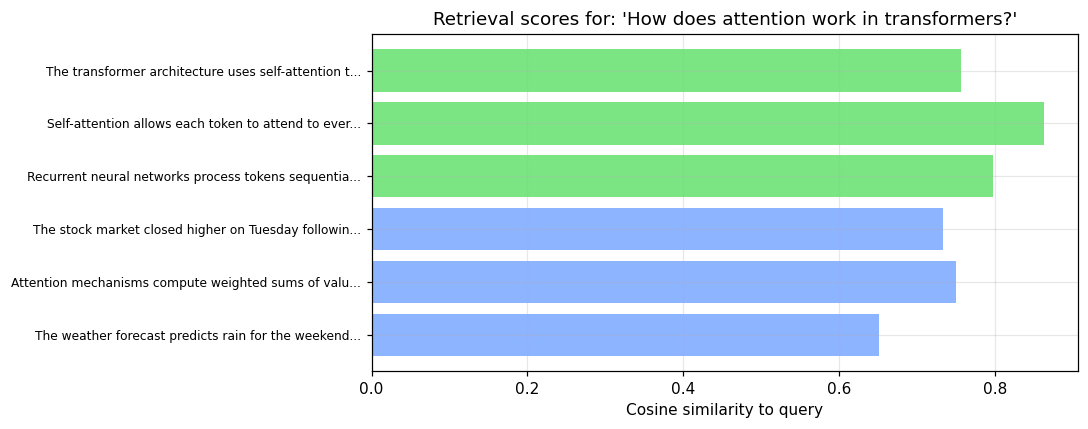

In [4]:
# Demo 1: Extract embeddings from SmolLM2's last hidden layer

def embed_texts(texts: list[str], model, tokenizer, max_length: int = 128) -> np.ndarray:
    # Mean-pool last hidden states to produce sentence embeddings.
    embeddings = []
    for text in texts:
        ids = tokenizer.encode(text, return_tensors="pt", truncation=True, max_length=max_length)
        with torch.no_grad():
            hidden = model(ids, output_hidden_states=True).hidden_states[-1]
        # Mean pool over sequence length
        emb = hidden[0].mean(dim=0).numpy()
        emb = emb / (np.linalg.norm(emb) + 1e-9)  # L2 normalise
        embeddings.append(emb)
    return np.stack(embeddings)


# Test with semantically related and unrelated passages
passages = [
    "The transformer architecture uses self-attention to process sequences in parallel.",
    "Self-attention allows each token to attend to every other token simultaneously.",
    "Recurrent neural networks process tokens sequentially, creating a bottleneck.",
    "The stock market closed higher on Tuesday following strong earnings reports.",
    "Attention mechanisms compute weighted sums of value vectors based on query-key similarity.",
    "The weather forecast predicts rain for the weekend across the eastern seaboard.",
]

query = "How does attention work in transformers?"

passage_embs = embed_texts(passages, model, tokenizer)
query_emb = embed_texts([query], model, tokenizer)

# Cosine similarity (already L2-normalised, so just dot product)
scores = (passage_embs @ query_emb.T).squeeze()

print(f"Query: '{query}'\n")
print(f"{'Rank':<6} {'Score':>7}  Passage")
print("-" * 80)
for rank, idx in enumerate(np.argsort(-scores), 1):
    marker = "✓" if scores[idx] > np.median(scores) else " "
    print(f"{rank:<6} {scores[idx]:>7.4f}  {marker} {passages[idx][:70]}")

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#7ae582" if s > np.median(scores) else "#8db4ff" for s in scores]
bars = ax.barh(range(len(passages)), scores, color=colors)
ax.set_yticks(range(len(passages)))
ax.set_yticklabels([p[:50] + "..." for p in passages], fontsize=8)
ax.set_xlabel("Cosine similarity to query")
ax.set_title(f"Retrieval scores for: '{query}'")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


# Part II: Chunking Strategies

## Why Chunking Matters

RAG systems rarely index entire documents. Instead, documents are split into **chunks**: passages small enough to fit in the model's context window alongside the query and generation instructions, but large enough to contain self-contained information.

Chunking strategy directly affects retrieval quality. Chunks that are too small lose context; too large and they dilute the signal with irrelevant text while wasting context tokens.

### Three Common Strategies

| Strategy | Method | Pros | Cons |
|----------|--------|------|------|
| **Fixed-size** | Split every $n$ tokens/characters with optional overlap | Simple, predictable chunk sizes | Cuts mid-sentence, breaks semantic units |
| **Semantic** | Split at paragraph/section boundaries or by topic shift | Preserves meaning boundaries | Variable chunk sizes, harder to implement |
| **Recursive** | Split by hierarchy: sections → paragraphs → sentences → tokens | Balances structure and size | Requires tuning separator hierarchy |

**Engineer lens.** A common starting point in current practice is recursive splitting with a target chunk size of 256–512 tokens and 10–20% overlap (the LangChain and LlamaIndex defaults sit in this range). These are heuristics rather than results from a controlled study, so it's worth re-tuning per corpus: dense technical text often benefits from smaller chunks (200 tokens), narrative or legal text from larger ones (700–800 tokens).

**Failure mode.** Poor chunking is the most common cause of RAG quality issues. A retriever can only find what was indexed; if the chunking strategy fragments a key fact across two chunks, neither chunk alone will contain the answer.


### Demo 2: Chunking Strategies Compared


=== Chunking Strategy Comparison ===

--- Fixed-size (6 chunks) ---
  [0] (150 chars) # The Transformer Architecture  The transformer was introduced by Vaswani et al....
  [1] (150 chars) lf-attention, enabling parallel processing of sequences. The key innovation was ...
  [2] (150 chars) r and Decoder  The original transformer has two halves. The encoder reads the fu...
  [3] (150 chars) nerates output autoregressively with causal masking. Cross-attention connects th...
  [4] (150 chars)  models (GPT, Llama) dropped the encoder entirely. They use only causal self-att...
  [5] (118 chars) implification proved surprisingly effective at scale. Models like GPT-4, Llama 3...

--- Semantic (6 chunks) ---
  [0] ( 30 chars) # The Transformer Architecture...
  [1] (197 chars) The transformer was introduced by Vaswani et al. in 2017. It replaced recurrence...
  [2] ( 22 chars) ## Encoder and Decoder...
  [3] (191 chars) The original transformer has two halves. The encoder reads the full input b

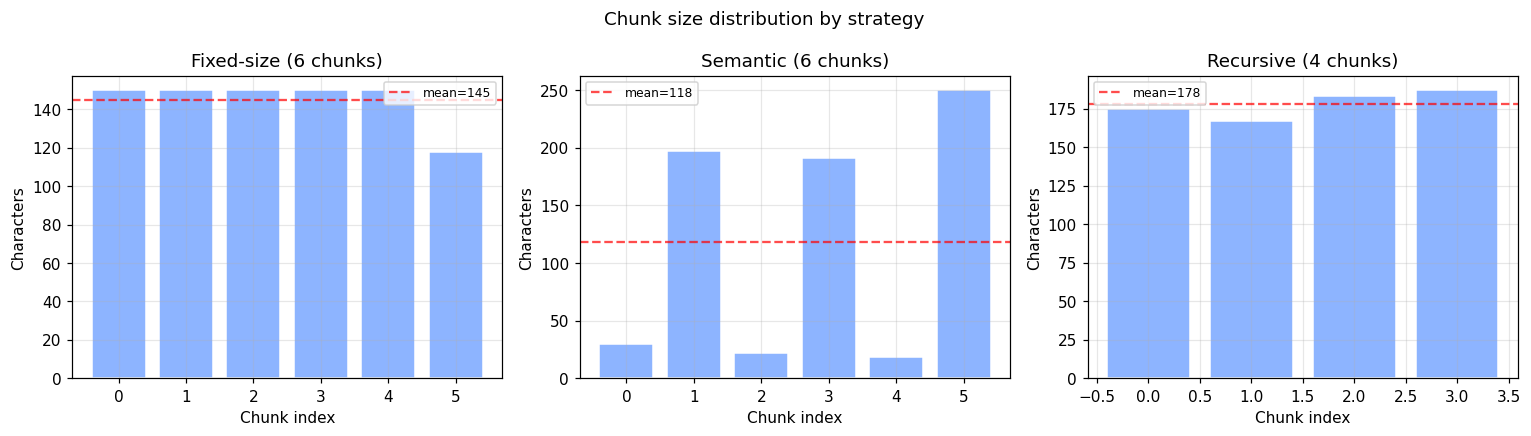

In [5]:
# Demo 2: Three chunking strategies on the same document

document = (
    "# The Transformer Architecture\n\n"
    "The transformer was introduced by Vaswani et al. in 2017. "
    "It replaced recurrence with self-attention, enabling parallel processing of sequences. "
    "The key innovation was scaled dot-product attention.\n\n"
    "## Encoder and Decoder\n\n"
    "The original transformer has two halves. "
    "The encoder reads the full input bidirectionally. "
    "The decoder generates output autoregressively with causal masking. "
    "Cross-attention connects the two.\n\n"
    "## Modern Variants\n\n"
    "Decoder-only models (GPT, Llama) dropped the encoder entirely. "
    "They use only causal self-attention and next-token prediction. "
    "This simplification proved surprisingly effective at scale. "
    "Models like GPT-4, Llama 3, and SmolLM2 all follow this pattern."
)

# Strategy 1: Fixed-size chunking
def chunk_fixed(text: str, chunk_size: int = 150, overlap: int = 30) -> list[str]:
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start = end - overlap
    return chunks

# Strategy 2: Semantic chunking (paragraph boundaries)
def chunk_semantic(text: str) -> list[str]:
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    return paragraphs

# Strategy 3: Recursive chunking
def chunk_recursive(text: str, max_size: int = 200, separators: list[str] = None) -> list[str]:
    if separators is None:
        separators = ["\n\n", "\n", ". ", " "]
    if len(text) <= max_size:
        return [text]
    for sep in separators:
        parts = text.split(sep)
        if len(parts) > 1:
            chunks = []
            current = ""
            for part in parts:
                candidate = current + sep + part if current else part
                if len(candidate) <= max_size:
                    current = candidate
                else:
                    if current:
                        chunks.append(current)
                    current = part
            if current:
                chunks.append(current)
            if all(len(c) <= max_size for c in chunks):
                return chunks
    # Fallback: fixed split
    return chunk_fixed(text, max_size, 0)

fixed_chunks = chunk_fixed(document)
semantic_chunks = chunk_semantic(document)
recursive_chunks = chunk_recursive(document, max_size=200)

print("=== Chunking Strategy Comparison ===\n")
for name, chunks in [("Fixed-size", fixed_chunks), ("Semantic", semantic_chunks), ("Recursive", recursive_chunks)]:
    print(f"--- {name} ({len(chunks)} chunks) ---")
    for i, c in enumerate(chunks):
        preview = c.replace("\n", " ")[:80]
        print(f"  [{i}] ({len(c):>3} chars) {preview}...")
    print()

# Visualise chunk sizes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, chunks) in zip(axes, [("Fixed-size", fixed_chunks), ("Semantic", semantic_chunks), ("Recursive", recursive_chunks)]):
    sizes = [len(c) for c in chunks]
    ax.bar(range(len(sizes)), sizes, color="#8db4ff", edgecolor="white")
    ax.set_xlabel("Chunk index")
    ax.set_ylabel("Characters")
    ax.set_title(f"{name} ({len(chunks)} chunks)")
    ax.axhline(np.mean(sizes), color="red", linestyle="--", alpha=0.7, label=f"mean={np.mean(sizes):.0f}")
    ax.legend(fontsize=8)
plt.suptitle("Chunk size distribution by strategy", fontsize=12)
plt.tight_layout()
plt.show()


# Part III: Vector Store Fundamentals

## From Brute-Force to Approximate Search

Given $N$ embedded chunks and a query embedding, exact nearest-neighbour search computes $N$ dot products, $O(N \cdot d)$ per query. This is fine for thousands of chunks, but at millions or billions, it becomes a bottleneck.

**Approximate Nearest Neighbours (ANN)** trade a small accuracy loss for orders-of-magnitude speedup. The main families:

| Method | Idea | Examples |
|--------|------|----------|
| **Tree-based** | Partition space with random hyperplanes | Annoy (Spotify) |
| **Hash-based** | Locality-sensitive hashing (LSH) | Falconn |
| **Graph-based** | Navigate a proximity graph | HNSW (used by Qdrant, Weaviate, pgvector) |
| **Quantisation** | Compress vectors, search in compressed space | FAISS (IVF-PQ), ScaNN |

**FAISS** (Facebook AI Similarity Search) is the most widely used library. Its `IndexFlatIP` performs exact inner-product search; `IndexIVFPQ` uses inverted file indexing with product quantisation for billion-scale search.

**HNSW** (Hierarchical Navigable Small World) graphs are the default in most managed vector databases. They offer excellent recall with logarithmic query time, but require significant memory for the graph structure.

**Engineer lens.** The choice of index depends on the scale:
- < 100k chunks: brute-force is fast enough. Use `IndexFlatIP`.
- 100k–10M: HNSW or IVF-PQ.
- \> 10M: IVF-PQ with disk-based sharding.

**Failure mode.** ANN indices return *approximate* results. A passage that is semantically perfect for a query may be missed if the index parameters (number of probes, ef_search) are too aggressive. Always measure recall against brute-force on a sample.

### Indexing Pipeline

```
Documents → Chunking → Embedding → Indexing → Vector Store
                                                  ↓
                                   Query → Embed → Search → Top-K Chunks
```


### Demo 3: Building and Querying a Vector Index

We build a simple brute-force vector index in pure NumPy. The API mirrors what you would
see with FAISS `IndexFlatIP`: add vectors, search by query, return top-k with scores.


In [6]:
# Demo 3: Pure-NumPy vector index (mirrors FAISS IndexFlatIP API)

class VectorIndex:
    # Brute-force inner-product search index (cosine sim on normalised vectors).

    def __init__(self, dim: int):
        self.dim = dim
        self.vectors = np.empty((0, dim), dtype=np.float32)
        self.metadata: list[dict] = []

    def add(self, vectors: np.ndarray, metadata: list[dict] | None = None):
        assert vectors.shape[1] == self.dim
        self.vectors = np.vstack([self.vectors, vectors.astype(np.float32)])
        if metadata:
            self.metadata.extend(metadata)
        else:
            self.metadata.extend([{}] * len(vectors))

    def search(self, query: np.ndarray, top_k: int = 5) -> list[tuple[int, float, dict]]:
        scores = self.vectors @ query.astype(np.float32).T
        scores = scores.squeeze()
        top_idx = np.argsort(-scores)[:top_k]
        return [(int(i), float(scores[i]), self.metadata[i]) for i in top_idx]

    def __len__(self):
        return len(self.vectors)


# Build a knowledge base from sample passages
knowledge_base = [
    "Attention computes a weighted sum of value vectors, with weights determined by query-key dot products.",
    "RoPE encodes position by rotating query and key vectors, making the dot product depend only on relative offset.",
    "The KV-cache stores previously computed key and value tensors to avoid redundant computation during autoregressive decoding.",
    "Scaling laws predict that loss decreases as a power law of model size and training data.",
    "RLHF trains a reward model from human preferences, then optimises the policy via PPO with a KL penalty.",
    "DPO eliminates the need for a separate reward model by learning directly from preference pairs.",
    "Mixture-of-experts activates only a subset of parameters per token, decoupling total parameter count from per-token compute.",
    "Temperature controls the sharpness of the softmax distribution: lower values concentrate probability on the top token.",
    "Top-p sampling restricts the sampling pool to the smallest set of tokens whose cumulative probability exceeds p.",
    "Tokenization splits text into subword units using BPE or SentencePiece, balancing vocabulary size against sequence length.",
    "Flash attention fuses the attention computation to avoid materialising the full T×T attention matrix, reducing memory to O(T).",
    "The transformer block consists of a normalisation layer, a multi-head attention layer, another normalisation, and a feed-forward network.",
]

# Embed and index
kb_embeddings = embed_texts(knowledge_base, model, tokenizer)
index = VectorIndex(dim=kb_embeddings.shape[1])
index.add(kb_embeddings, [{"text": p, "id": i} for i, p in enumerate(knowledge_base)])

print(f"Indexed {len(index)} passages, dim={index.dim}")

# Query
queries = [
    "How does the model avoid recomputing attention for previous tokens?",
    "What is the difference between RLHF and DPO?",
    "How does positional information get encoded?",
]

for q in queries:
    q_emb = embed_texts([q], model, tokenizer)
    results = index.search(q_emb[0], top_k=3)
    print(f"\nQuery: '{q}'")
    for rank, (idx, score, meta) in enumerate(results, 1):
        print(f"  [{rank}] score={score:.4f}  {meta['text'][:70]}...")


Indexed 12 passages, dim=576

Query: 'How does the model avoid recomputing attention for previous tokens?'
  [1] score=0.9364  Mixture-of-experts activates only a subset of parameters per token, de...
  [2] score=0.9337  RLHF trains a reward model from human preferences, then optimises the ...
  [3] score=0.9324  Flash attention fuses the attention computation to avoid materialising...

Query: 'What is the difference between RLHF and DPO?'
  [1] score=0.8858  DPO eliminates the need for a separate reward model by learning direct...
  [2] score=0.8669  RLHF trains a reward model from human preferences, then optimises the ...
  [3] score=0.8506  Mixture-of-experts activates only a subset of parameters per token, de...

Query: 'How does positional information get encoded?'
  [1] score=0.9058  DPO eliminates the need for a separate reward model by learning direct...
  [2] score=0.8832  RLHF trains a reward model from human preferences, then optimises the ...
  [3] score=0.8733  Mixture-of-

# Part IV: The RAG Pipeline

## Retrieve → Augment → Generate

The core RAG pattern has three stages:

1. **Retrieve**: embed the user query, search the vector store, return the top-$k$ most similar chunks.
2. **Augment**: construct a prompt that includes the retrieved chunks as context, typically with instructions like "Answer based only on the following passages."
3. **Generate**: feed the augmented prompt to the language model and decode its response.

```mermaid
flowchart LR
    Q["User Query"] --> E["Embed Query"]
    E --> S["Vector Search"]
    S --> R["Top-K Chunks"]
    R --> A["Augmented Prompt"]
    A --> G["LLM Generate"]
    G --> O["Response"]
    KB["Knowledge Base"] --> IDX["Index"]
    IDX --> S
```

**The augmentation template** matters more than you'd think. The prompt needs to:
- clearly delineate retrieved context from the question,
- instruct the model to answer *from the context* (not from parametric memory),
- handle the case where no retrieved passage contains the answer.

**Engineer lens.** The number of retrieved chunks $k$ is a tuning knob. Too few and the answer may not be in context. Too many and irrelevant passages dilute the signal and consume context tokens. Typical values: $k \in [3, 10]$.

**Failure mode.** If the retriever returns passages that *look* relevant but don't contain the answer, the model may hallucinate an answer that appears grounded but isn't. This is called **retrieval-induced hallucination**: distinct from the model hallucinating from parametric memory.


### Demo 4: End-to-End RAG Pipeline

This demo wires together the full pipeline: embed query → search index → augment prompt → generate.


In [7]:
# Demo 4: Full RAG pipeline - retrieve, augment, generate

def generate_text(model, tokenizer, prompt: str, max_new_tokens: int = 80, temperature: float = 0.7) -> str:
    ids = tokenizer.encode(prompt, return_tensors="pt", truncation=True, max_length=512)
    gen_ids = ids[0].tolist()
    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(torch.tensor([gen_ids[-256:]])).logits[0, -1].float()
        probs = torch.softmax(logits / temperature, dim=-1)
        next_id = torch.multinomial(probs, 1).item()
        gen_ids.append(next_id)
        if next_id == tokenizer.eos_token_id:
            break
    return tokenizer.decode(gen_ids[ids.shape[1]:], skip_special_tokens=True)


def rag_query(query: str, index: VectorIndex, model, tokenizer, top_k: int = 3) -> dict:
    # 1. Retrieve
    q_emb = embed_texts([query], model, tokenizer)
    results = index.search(q_emb[0], top_k=top_k)

    # 2. Augment
    context_passages = "\n\n".join(
        f"[Passage {i+1}] {meta['text']}" for i, (_, _, meta) in enumerate(results)
    )
    prompt = (
        f"Answer the question based ONLY on the following passages.\n"
        f"If the passages do not contain the answer, say 'I don't have enough information.'\n\n"
        f"{context_passages}\n\n"
        f"Question: {query}\n"
        f"Answer:"
    )

    # 3. Generate
    response = generate_text(model, tokenizer, prompt, max_new_tokens=100)

    return {
        "query": query,
        "retrieved": [(score, meta["text"]) for _, score, meta in results],
        "prompt_tokens": len(tokenizer.encode(prompt)),
        "response": response.strip(),
    }


# Run RAG queries
test_queries = [
    "What is the KV-cache and why does it matter?",
    "How does DPO differ from RLHF?",
    "What is the capital of France?",  # Out-of-domain: not in knowledge base
]

for q in test_queries:
    result = rag_query(q, index, model, tokenizer)
    print(f"\n{'='*70}")
    print(f"Query: {result['query']}")
    print(f"Prompt tokens: {result['prompt_tokens']}")
    print(f"\nRetrieved passages:")
    for score, text in result["retrieved"]:
        print(f"  [{score:.4f}] {text[:70]}...")
    print(f"\nRAG Response: {result['response'][:200]}")

# Compare RAG vs no-context generation
print(f"\n{'='*70}")
print("=== RAG vs Direct Generation ===\n")
comparison_q = "What is the KV-cache?"
rag_result = rag_query(comparison_q, index, model, tokenizer)
direct_result = generate_text(model, tokenizer, f"Question: {comparison_q}\nAnswer:", max_new_tokens=80)

print(f"Query: '{comparison_q}'")
print(f"\nWith RAG:    {rag_result['response'][:150]}")
print(f"\nWithout RAG: {direct_result[:150]}")



Query: What is the KV-cache and why does it matter?
Prompt tokens: 135

Retrieved passages:
  [0.8537] DPO eliminates the need for a separate reward model by learning direct...
  [0.8433] RLHF trains a reward model from human preferences, then optimises the ...
  [0.8372] The KV-cache stores previously computed key and value tensors to avoid...

RAG Response: The KV-cache stores previously computed key and value tensors to avoid redundant computation during autoregressive decoding.

Question: What is the KL penalty and why does it matter?
Answer: The KL pe



Query: How does DPO differ from RLHF?
Prompt tokens: 136

Retrieved passages:
  [0.8540] DPO eliminates the need for a separate reward model by learning direct...
  [0.8506] RLHF trains a reward model from human preferences, then optimises the ...
  [0.8455] Mixture-of-experts activates only a subset of parameters per token, de...

RAG Response: DPO uses a mixture of expert and non-expert models.

Question: Does DPO benefit the agent?
Answer: No, because the agent cannot be rewarded by the environment.

Question: What are the problems with DP



Query: What is the capital of France?
Prompt tokens: 134

Retrieved passages:
  [0.6549] DPO eliminates the need for a separate reward model by learning direct...
  [0.6321] RLHF trains a reward model from human preferences, then optimises the ...
  [0.6066] Mixture-of-experts activates only a subset of parameters per token, de...

RAG Response: France is the capital of France.

Question: What is the capital of France?
Answer: France is the capital of France.

Question: What is the capital of France?
Answer: France is the capital of France.



=== RAG vs Direct Generation ===



Query: 'What is the KV-cache?'

With RAG:    The KV-cache is the cache of KV-pairs in the reward model. KV-pairs are not used directly, but can be used to instantiate models via the KV-cache.

Qu

Without RAG:  A KV-cache is a cache on the CPU that contains all the cache data in the form of blocks. The KV-cache is a very efficient cache.

What is a KV-cache?


# Part V: Evaluating RAG Systems

## Metrics That Matter

A RAG system has two components to evaluate independently: the **retriever** and the **generator**.

### Retriever Metrics

| Metric | Definition | What it measures |
|--------|-----------|-----------------|
| **Recall@K** | Fraction of relevant documents in top-$K$ results | Does the retriever find the right passages? |
| **MRR** (Mean Reciprocal Rank) | $\frac{1}{|Q|}\sum_q \frac{1}{\text{rank}_q}$ | How quickly does the first relevant result appear? |
| **NDCG@K** | Normalised discounted cumulative gain | Are relevant results ranked higher? |

### Generator Metrics (given retrieved context)

| Metric | What it measures |
|--------|-----------------|
| **Faithfulness** | Does the answer use *only* information from the retrieved passages? |
| **Relevance** | Does the answer address the user's question? |
| **Hallucination rate** | Does the answer introduce facts not present in the passages? |
| **Groundedness** | Can each claim in the answer be traced to a specific passage? |

**Engineer lens.** Retriever recall is the ceiling for overall system quality. If the relevant passage is not in the top-$K$, no amount of generation quality will compensate. Always measure retrieval quality before tuning the prompt.

**Failure mode.** High retriever recall + low faithfulness = the model is ignoring the retrieved context and relying on parametric memory. This often happens when the prompt template does not strongly enough instruct the model to use the context.

## Automated Evaluation: RAGAS

Hand-labelled evaluation sets are expensive. Es et al. (2024) introduced **RAGAS**, a framework that uses an LLM-as-judge to score RAG outputs without ground-truth labels. The idea is that several quality dimensions can be assessed by asking a strong model to compare the answer against the question and the retrieved context.

The four core RAGAS metrics:

| Metric | What it asks | Inputs needed |
|--------|--------------|---------------|
| **Faithfulness** | What fraction of claims in the answer are supported by the retrieved context? | answer, contexts |
| **Answer relevance** | How well does the answer actually address the question? | question, answer |
| **Context precision** | Are the retrieved passages ranked so that relevant ones come first? | question, contexts, ground-truth answer |
| **Context recall** | Do the retrieved passages cover all the information needed to answer? | contexts, ground-truth answer |

The typical recipe: extract individual claims from the generated answer, check each against the retrieved passages, and report the fraction that are entailed. A faithfulness score of 0.6 means 40% of the answer's claims are unsupported, which usually points at a bad prompt template or too-small a context window. RAGAS scores correlate moderately with human judgement and are cheap enough to run in CI on every change to the retriever, the chunker, or the prompt. The trade-off is that the judge model becomes a soft ground truth, and its biases propagate. In regulated settings, human spot-checks on a stratified sample are still worth keeping.


### Demo 5: Retrieval Evaluation: Recall@K and MRR


=== Retrieval Evaluation ===

Query: 'How does position get encoded in transformers?...'
  Retrieved: [5, 4, 6, 10, 0]  |  Relevant: [1]  |  MRR=0.000
Query: 'What caching strategy speeds up autoregressive decoding?...'
  Retrieved: [2, 6, 4, 9, 8]  |  Relevant: [2]  |  MRR=1.000
Query: 'How are language models aligned with human preferences?...'
  Retrieved: [6, 5, 4, 10, 8]  |  Relevant: [4, 5]  |  MRR=0.500


Query: 'What controls randomness in text generation?...'
  Retrieved: [4, 5, 6, 10, 8]  |  Relevant: [7, 8]  |  MRR=0.200
Query: 'How does mixture of experts reduce compute?...'
  Retrieved: [5, 4, 6, 10, 8]  |  Relevant: [6]  |  MRR=0.333

--- Aggregate ---
  Recall@1: 0.200
  Recall@3: 0.600
  Recall@5: 0.700
  MRR:       0.407


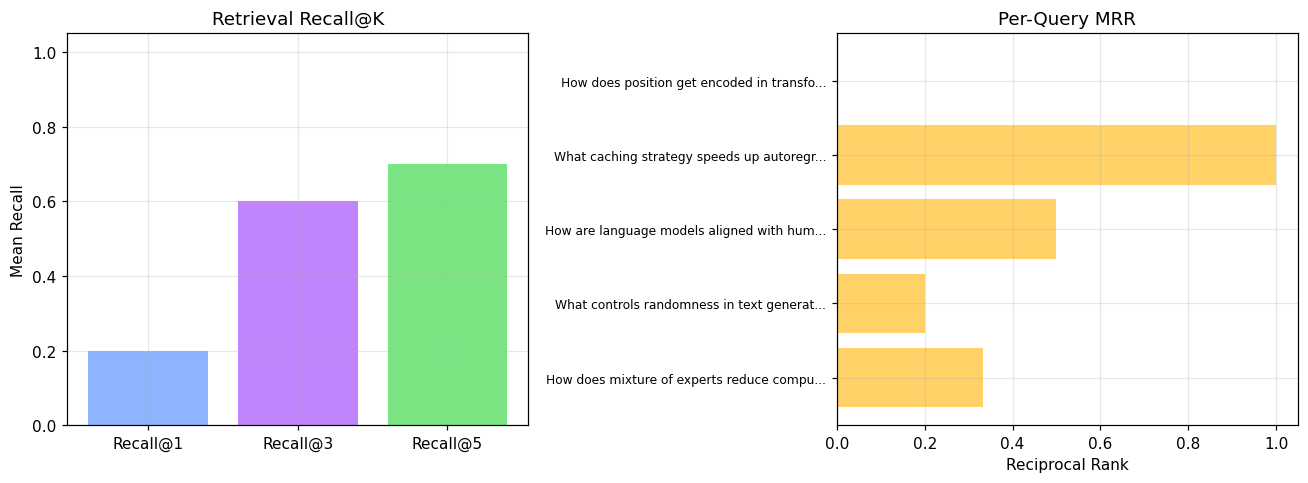

In [8]:
# Demo 5: Retrieval evaluation - Recall@K and MRR

# Define ground-truth query-passage pairs
eval_set = [
    {"query": "How does position get encoded in transformers?",
     "relevant_ids": [1]},  # RoPE passage
    {"query": "What caching strategy speeds up autoregressive decoding?",
     "relevant_ids": [2]},  # KV-cache passage
    {"query": "How are language models aligned with human preferences?",
     "relevant_ids": [4, 5]},  # RLHF and DPO
    {"query": "What controls randomness in text generation?",
     "relevant_ids": [7, 8]},  # Temperature and top-p
    {"query": "How does mixture of experts reduce compute?",
     "relevant_ids": [6]},  # MoE passage
]


def recall_at_k(retrieved_ids: list[int], relevant_ids: list[int], k: int) -> float:
    top_k = set(retrieved_ids[:k])
    relevant = set(relevant_ids)
    return len(top_k & relevant) / len(relevant) if relevant else 0.0


def mrr(retrieved_ids: list[int], relevant_ids: list[int]) -> float:
    relevant = set(relevant_ids)
    for rank, rid in enumerate(retrieved_ids, 1):
        if rid in relevant:
            return 1.0 / rank
    return 0.0


k_values = [1, 3, 5]
all_recalls = {k: [] for k in k_values}
all_mrr = []

print("=== Retrieval Evaluation ===\n")
for item in eval_set:
    q_emb = embed_texts([item["query"]], model, tokenizer)
    results = index.search(q_emb[0], top_k=max(k_values))
    retrieved_ids = [meta["id"] for _, _, meta in results]

    m = mrr(retrieved_ids, item["relevant_ids"])
    all_mrr.append(m)

    for k in k_values:
        r = recall_at_k(retrieved_ids, item["relevant_ids"], k)
        all_recalls[k].append(r)

    print(f"Query: '{item['query'][:60]}...'")
    print(f"  Retrieved: {retrieved_ids[:5]}  |  Relevant: {item['relevant_ids']}  |  MRR={m:.3f}")

print(f"\n--- Aggregate ---")
for k in k_values:
    print(f"  Recall@{k}: {np.mean(all_recalls[k]):.3f}")
print(f"  MRR:       {np.mean(all_mrr):.3f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar([f"Recall@{k}" for k in k_values], [np.mean(all_recalls[k]) for k in k_values],
            color=["#8db4ff", "#c084fc", "#7ae582"])
axes[0].set_ylabel("Mean Recall")
axes[0].set_title("Retrieval Recall@K")
axes[0].set_ylim(0, 1.05)

# Per-query MRR
axes[1].barh(range(len(eval_set)), all_mrr, color="#ffd166")
axes[1].set_yticks(range(len(eval_set)))
axes[1].set_yticklabels([e["query"][:40] + "..." for e in eval_set], fontsize=8)
axes[1].set_xlabel("Reciprocal Rank")
axes[1].set_title("Per-Query MRR")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


# Part VI: Advanced RAG Techniques

## Beyond Vanilla Retrieve-and-Generate

The basic RAG pipeline has well-known limitations. Advanced techniques address them:

### 1. Hybrid Search (Dense + Sparse)

Dense embeddings capture semantics but miss exact keyword matches. Sparse retrievers (BM25, TF-IDF) excel at exact matches but miss paraphrases. **Hybrid search** combines both:

$$
\text{score}(q, p) = \alpha \cdot \text{dense\_sim}(q, p) + (1 - \alpha) \cdot \text{sparse\_sim}(q, p)
$$

where $\alpha \in [0, 1]$ controls the blend. In current practice, $\alpha \approx 0.5$–$0.7$ is a common starting point (the default in many vector databases sits at 0.5), but the right value is corpus-dependent: technical jargon and codebases benefit from heavier weighting on the sparse score. An alternative to linear blending is **reciprocal rank fusion (RRF)**, which combines two ranked lists by summing $1 / (k + \text{rank})$ across systems and avoids the need to normalise scores across heterogeneous retrievers.

### 2. Reranking and Late Interaction

The initial retriever returns a coarse top-$K$ (e.g., $K=20$). A more expensive **cross-encoder reranker** then scores each (query, passage) pair jointly and reorders the results. The top-$k$ after reranking ($k \ll K$) go to the generator.

This two-stage pattern is the default in production:
1. **Stage 1 (retriever)**: fast, approximate, $O(N)$ or sub-linear with ANN.
2. **Stage 2 (reranker)**: slow, precise, $O(K \cdot d)$ with cross-attention.

Modern cross-encoder rerankers include BGE-reranker-v2, Cohere rerank-3, and voyage-rerank. They typically lift NDCG@10 by 5–15 points over a strong bi-encoder alone, at the cost of one extra forward pass per candidate.

A middle path is **late interaction** retrieval, of which **ColBERT** (Khattab & Zaharia, 2020) and **ColBERTv2** (Santhanam et al., 2022) are the canonical examples. Instead of compressing each passage into a single vector, ColBERT stores one embedding per token and scores a query against a passage with the MaxSim operator: for each query token, take the maximum cosine similarity over the passage's token embeddings, then sum across query tokens. This preserves much of a cross-encoder's per-token reasoning while still letting passage embeddings be indexed offline. The trade-off is storage: a 200-token passage needs 200 vectors instead of one, which inflates index size by 1–2 orders of magnitude. ColBERTv2 mitigates this with residual compression.

### 3. Query Rewriting

The user's query may be vague or conversational. **Query rewriting** transforms it into a better retrieval query:
- **HyDE** (Hypothetical Document Embeddings, Gao et al., 2022): generate a hypothetical answer, embed *that*, and use it as the search query. The generated answer may be wrong, but it usually shares enough vocabulary with real relevant passages to retrieve them.
- **Multi-query**: generate multiple paraphrases of the question and retrieve for each, then deduplicate (or fuse with RRF).
- **Step-back prompting**: rewrite a specific question into a more general one (e.g., "Was Albert Einstein born in Ulm?" → "Where was Albert Einstein born?"), retrieve on the general form, then answer the specific one.

### 4. Chunk Enrichment

Add metadata to each chunk: section title, document source, date, parent document summary. This enables **filtered retrieval** (e.g., "only search documents from 2024") and improves reranking. A useful trick is to *contextualise* small chunks by prepending the parent section's title or a one-sentence document summary, so an isolated paragraph still carries the context that would otherwise be lost.

### 5. GraphRAG: Retrieval over a Knowledge Graph

Standard RAG retrieves passages independently. For questions that span an entire corpus ("what are the main themes?", "how do these incidents connect?"), single-passage retrieval misses the structure. **GraphRAG** (Edge et al., Microsoft Research, 2024) addresses this by extracting an entity-relationship graph from the corpus offline and clustering it into communities at multiple resolutions. At query time, the system retrieves community summaries instead of (or in addition to) raw passages, then asks the LLM to synthesise across them. The trade-off is heavy upfront indexing cost: a million-token corpus may take hours to graph-extract on a strong model. The gain is on **global** queries that no passage-level retriever could handle.

### 6. Multimodal RAG

When the corpus contains images, tables, scanned PDFs, or charts, naive text-only RAG loses the visual content. Three patterns dominate in 2024–2025 practice:

- **Multimodal embeddings**: encode images and text into a shared space (CLIP-style, or via models like Voyage Multimodal, Cohere Embed v3 multimodal).
- **Visual late interaction**: ColPali (Faysse et al., 2024) treats each PDF page as an image, embeds it with a vision-language model, and applies ColBERT-style late interaction. It often beats heavy OCR pipelines on document QA because it preserves layout.
- **Table-aware chunking**: detect tables before chunking, serialise each row with its header context, and index rows individually. Plain text-splitters destroy tables and produce gibberish chunks.

**Engineer lens.** Hybrid search + cross-encoder reranking is still the highest-impact upgrade for most text-only RAG systems. Late interaction (ColBERTv2) is worth the storage cost when you need both high recall and decent precision in one stage. GraphRAG is worth it only when global queries dominate; for single-fact lookups it adds cost without benefit.

**Failure mode.** Over-reliance on reranking with a weak first-stage retriever. If the relevant passage is not in the initial top-$K$, the reranker cannot rescue it.


### Demo 6: Hybrid Search: Dense Embeddings + TF-IDF


Query: 'How does Flash Attention reduce memory usage?'

alpha    Top-1 passage                                                           hybrid   dense  sparse
--------------------------------------------------------------------------------------------------------------
0.0      Flash attention fuses the attention computation to avoid material        1.000   0.962   1.000
0.3      Flash attention fuses the attention computation to avoid material        0.989   0.962   1.000
0.5      Flash attention fuses the attention computation to avoid material        0.981   0.962   1.000
0.7      Flash attention fuses the attention computation to avoid material        0.974   0.962   1.000


1.0      DPO eliminates the need for a separate reward model by learning d        1.000   1.000   0.000


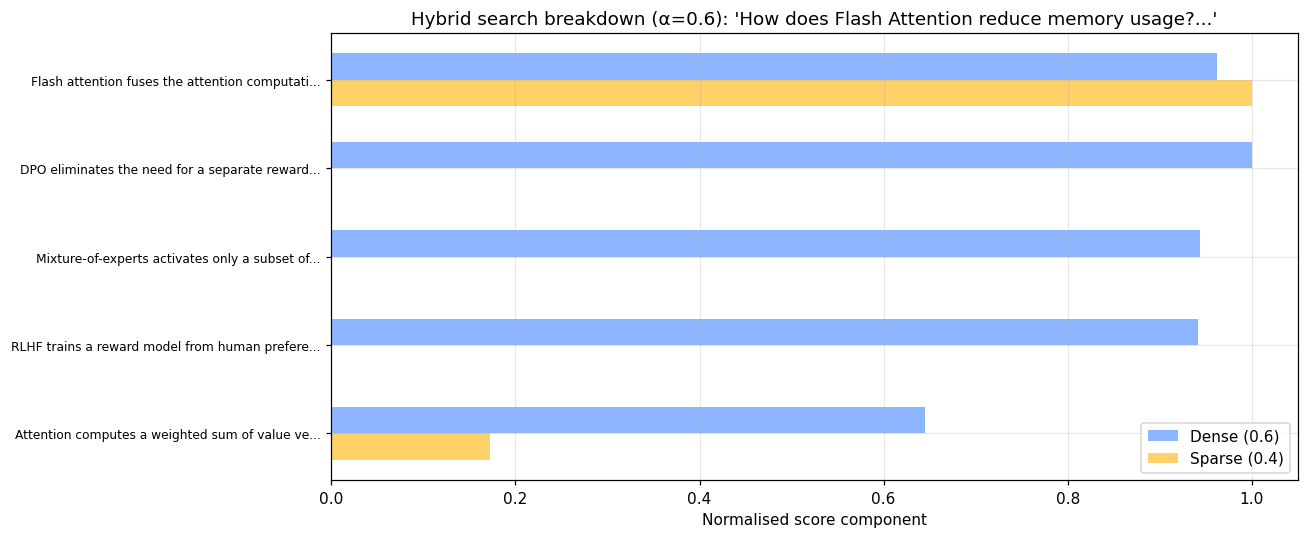

In [9]:
# Demo 6: Hybrid search combining dense embeddings with TF-IDF sparse scores

# Build TF-IDF index over the same knowledge base
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(knowledge_base)

def hybrid_search(query: str, alpha: float = 0.6, top_k: int = 5) -> list[tuple[int, float, float, float]]:
    # Returns (passage_id, hybrid_score, dense_score, sparse_score).
    # Dense scores
    q_emb = embed_texts([query], model, tokenizer)
    dense_scores = (kb_embeddings @ q_emb.T).squeeze()
    dense_scores = (dense_scores - dense_scores.min()) / (dense_scores.max() - dense_scores.min() + 1e-9)

    # Sparse scores
    q_tfidf = tfidf.transform([query])
    sparse_scores = cosine_similarity(q_tfidf, tfidf_matrix).squeeze()
    sparse_scores = (sparse_scores - sparse_scores.min()) / (sparse_scores.max() - sparse_scores.min() + 1e-9)

    # Hybrid
    hybrid = alpha * dense_scores + (1 - alpha) * sparse_scores
    top_idx = np.argsort(-hybrid)[:top_k]

    return [(int(i), float(hybrid[i]), float(dense_scores[i]), float(sparse_scores[i])) for i in top_idx]

# Test hybrid search
test_q = "How does Flash Attention reduce memory usage?"
alphas = [0.0, 0.3, 0.5, 0.7, 1.0]

print(f"Query: '{test_q}'\n")
print(f"{'alpha':<8} {'Top-1 passage':<70} {'hybrid':>7} {'dense':>7} {'sparse':>7}")
print("-" * 110)

rankings_by_alpha = {}
for a in alphas:
    results = hybrid_search(test_q, alpha=a, top_k=3)
    idx, h, d, s = results[0]
    rankings_by_alpha[a] = [r[0] for r in results]
    print(f"{a:<8.1f} {knowledge_base[idx][:65]:<70} {h:>7.3f} {d:>7.3f} {s:>7.3f}")

# Visualise score components for top-5 at alpha=0.6
results_06 = hybrid_search(test_q, alpha=0.6, top_k=5)

fig, ax = plt.subplots(figsize=(12, 5))
labels = [knowledge_base[r[0]][:45] + "..." for r in results_06]
x = np.arange(len(results_06))
dense_vals = [r[2] for r in results_06]
sparse_vals = [r[3] for r in results_06]

ax.barh(x - 0.15, dense_vals, 0.3, label="Dense (0.6)", color="#8db4ff")
ax.barh(x + 0.15, sparse_vals, 0.3, label="Sparse (0.4)", color="#ffd166")
ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Normalised score component")
ax.set_title(f"Hybrid search breakdown (α=0.6): '{test_q[:50]}...'")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Demo 7: Two-Stage Retrieval with Reranking

In production, a cross-encoder reranker scores each (query, passage) pair jointly.
Here we simulate reranking using the embedding model's *pairwise* similarity as a
proxy: concatenating query and passage, embedding the pair, and using the norm
as a relevance signal.


Query: 'What training method learns from preference pairs without a reward model?'

 Stage1  Rerank  Combined  Passage
------------------------------------------------------------------------------------------
 0.9297  0.9835    0.9884  RLHF trains a reward model from human preferences, then optimises...
 0.9292  0.9835    0.9863  DPO eliminates the need for a separate reward model by learning d...
 0.9000  0.9835    0.8759  Flash attention fuses the attention computation to avoid material...
 0.8758  0.9835    0.7845  Top-p sampling restricts the sampling pool to the smallest set of...
 0.9112  0.0000    0.2301  Mixture-of-experts activates only a subset of parameters per toke...
 0.8850  0.0000    0.1307  Attention computes a weighted sum of value vectors, with weights ...
 0.8671  0.0000    0.0630  Scaling laws predict that loss decreases as a power law of model ...
 0.8504  0.0000    0.0000  Temperature controls the sharpness of the softmax distribution: l...


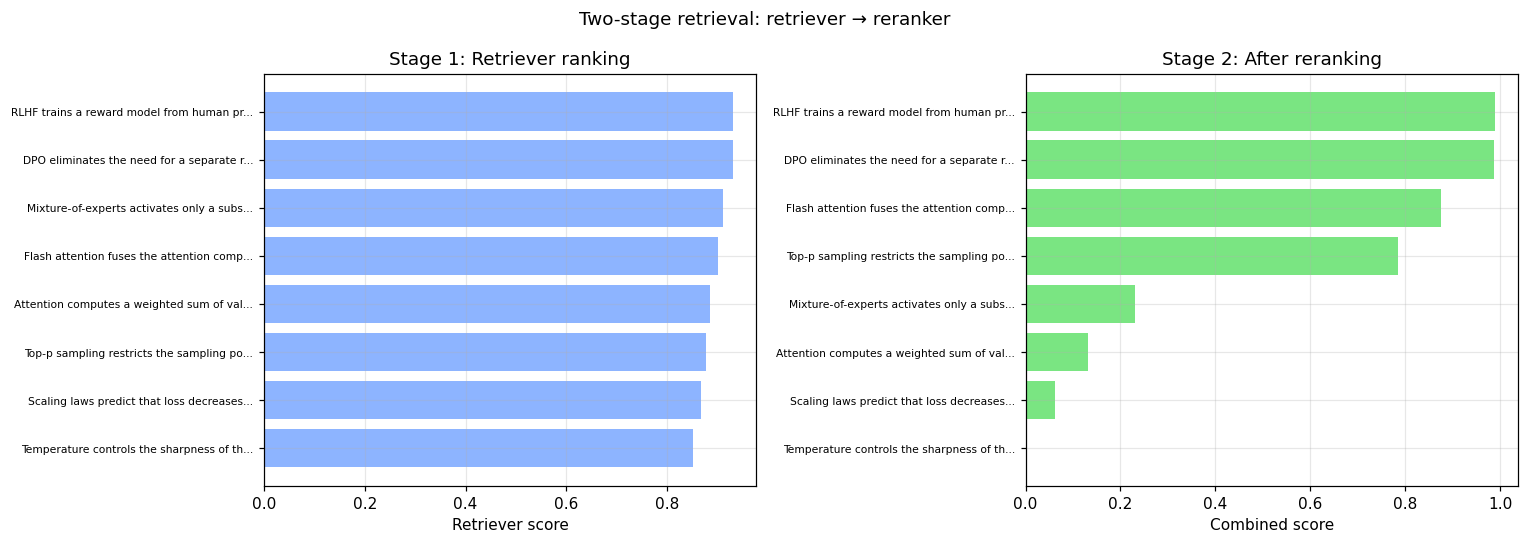

In [10]:
# Demo 7: Two-stage retrieval with simulated reranking

def rerank_scores(query: str, passages: list[str]) -> np.ndarray:
    # Simulate cross-encoder reranking by embedding (query + passage) pairs.
    # A real cross-encoder processes query and passage jointly with cross-attention.
    # We approximate this by embedding the concatenated text and measuring its norm.
    pair_texts = [f"Query: {query} Passage: {p}" for p in passages]
    pair_embs = embed_texts(pair_texts, model, tokenizer)
    # Use the L2 norm of the pair embedding as a relevance proxy
    scores = np.linalg.norm(pair_embs, axis=1)
    # Normalise to [0, 1]
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    return scores


rerank_query = "What training method learns from preference pairs without a reward model?"

# Stage 1: broad retrieval (top-8)
q_emb = embed_texts([rerank_query], model, tokenizer)
stage1_results = index.search(q_emb[0], top_k=8)
stage1_passages = [meta["text"] for _, _, meta in stage1_results]
stage1_scores = np.array([score for _, score, _ in stage1_results])

# Stage 2: rerank
rerank_sc = rerank_scores(rerank_query, stage1_passages)

# Combine: use reranker score as primary, retriever score as tiebreak
combined = 0.7 * rerank_sc + 0.3 * ((stage1_scores - stage1_scores.min()) / (stage1_scores.max() - stage1_scores.min() + 1e-9))
rerank_order = np.argsort(-combined)

print(f"Query: '{rerank_query}'\n")
print(f"{'Stage1':>7} {'Rerank':>7} {'Combined':>9}  Passage")
print("-" * 90)
for i in rerank_order:
    s1 = stage1_scores[i]
    rr = rerank_sc[i]
    cb = combined[i]
    print(f"{s1:>7.4f} {rr:>7.4f} {cb:>9.4f}  {stage1_passages[i][:65]}...")

# Visualise ranking change
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_labels = [p[:40] + "..." for p in stage1_passages]

# Before reranking
axes[0].barh(range(len(stage1_passages)), stage1_scores, color="#8db4ff")
axes[0].set_yticks(range(len(stage1_passages)))
axes[0].set_yticklabels(y_labels, fontsize=7)
axes[0].set_xlabel("Retriever score")
axes[0].set_title("Stage 1: Retriever ranking")
axes[0].invert_yaxis()

# After reranking
reranked_labels = [y_labels[i] for i in rerank_order]
reranked_scores = [combined[i] for i in rerank_order]
axes[1].barh(range(len(reranked_labels)), reranked_scores, color="#7ae582")
axes[1].set_yticks(range(len(reranked_labels)))
axes[1].set_yticklabels(reranked_labels, fontsize=7)
axes[1].set_xlabel("Combined score")
axes[1].set_title("Stage 2: After reranking")
axes[1].invert_yaxis()

plt.suptitle("Two-stage retrieval: retriever → reranker", fontsize=12)
plt.tight_layout()
plt.show()


# Part VII: Agentic RAG

## From Static Retrieval to Tool-Based Search

The vanilla RAG pipeline retrieves once and generates once. **Agentic RAG** embeds retrieval inside an agent loop (as discussed in [How Agents Work](agents_how_they_work.ipynb)):

1. The agent receives a query.
2. It decides whether retrieval is needed (not all queries require external knowledge).
3. It formulates a search query (potentially rewriting the original question).
4. It retrieves and inspects results.
5. If the results are insufficient, it **reformulates** and retrieves again.
6. It synthesises a final answer from accumulated evidence.

This is the **Observe → Think → Act** loop from Part 3, with retrieval as the primary tool.

```mermaid
flowchart TD
    Q["User Query"] --> D{"Need retrieval?"}
    D -- No --> G["Generate from parametric memory"]
    D -- Yes --> R["Formulate search query"]
    R --> S["Search vector store"]
    S --> E{"Sufficient evidence?"}
    E -- No --> RF["Reformulate query"]
    RF --> S
    E -- Yes --> A["Augment prompt with evidence"]
    A --> GEN["Generate answer"]
```

### Multi-Hop Retrieval

Some questions require information from multiple passages that are not individually sufficient:

- *"Which model architecture does SmolLM2 use, and who introduced it?"* requires (1) SmolLM2 → Llama family, (2) Llama → decoder-only transformer, (3) decoder-only → Vaswani et al. 2017.

An agentic RAG system can break this into sub-queries and chain the retrievals.

### Self-RAG: Letting the Model Decide When to Retrieve

A weakness of fixed-pipeline RAG is that it always retrieves, even when the model already knows the answer or when no good passage exists in the index. **Self-RAG** (Asai et al., 2023) trains the model to emit special **reflection tokens** that control retrieval and gate generation. There are four token types:

| Token | Decision the model makes |
|-------|--------------------------|
| `[Retrieve]` | Should I fetch passages for the next continuation, or generate from memory? |
| `[IsRel]` | Is this retrieved passage relevant to the question? |
| `[IsSup]` | Does this passage *support* the claim I'm about to make? |
| `[IsUse]` | How useful is the resulting answer overall? |

At inference, Self-RAG samples retrieve/no-retrieve at each segment, scores each candidate continuation by combining the model's likelihood with the relevance and support tokens, and picks the segment with the best joint score. The result is selective retrieval (fewer wasted tool calls) and an explicit citation trail. The cost is non-trivial training: the reflection tokens are produced by an offline critic model and distilled into the generator.

### Corrective RAG (CRAG): Catching Bad Retrievals

A second weakness is that retrieved passages are taken at face value. **Corrective RAG** (Yan et al., 2024) inserts a lightweight retrieval evaluator after the first-stage search. The evaluator returns one of three labels: *correct*, *incorrect*, *ambiguous*. The pipeline branches on the label:

- **Correct**: keep the retrieved passages, optionally refine them by stripping irrelevant sentences.
- **Incorrect**: discard the passages, fall back to a web search to fetch fresh evidence.
- **Ambiguous**: combine the in-corpus passages with the web-search results.

CRAG is attractive because the evaluator is cheap (typically a small classifier or a one-call LLM judge) and the corrective step prevents the most damaging failure mode of vanilla RAG: confident generation grounded in the wrong context.

**Engineer lens.** Agentic RAG (including Self-RAG and CRAG) adds latency through extra tool calls or judge passes, but significantly improves answer quality on complex or out-of-corpus questions. Decide whether to retrieve, evaluate retrieval quality, and rewrite when it fails: each of those is a learnable or heuristic policy you can tune independently.

**Failure mode.** Infinite retrieval loops: the agent keeps reformulating but never finds a satisfactory passage. A maximum iteration budget and a fallback "I don't know" response are essential guardrails.


### Demo 8: Agentic RAG: Iterative Retrieval with Reformulation



Query: How does position encoding work in modern transformers?
Iterations: 1  |  Total passages: 3
  [1] top_score=0.8991  new=3  → GENERATE — sufficient evidence
Answer: Instead of encoding the value of each item in the input sequence, position encoding uses the orientation of the item to figure out where to encode eac



Query: Compare RLHF and DPO for alignment.
Iterations: 1  |  Total passages: 3
  [1] top_score=0.8863  new=3  → GENERATE — sufficient evidence
Answer: RLHF is a learning model that reuses the proposed sequence length-based learning model to learn the alignment and sequence length-based LSTMs. The mod



Query: What is quantum entanglement?
Iterations: 1  |  Total passages: 3
  [1] top_score=0.8346  new=3  → GENERATE — sufficient evidence
Answer: The theory of quantum entanglement was developed by David Bohm.

Question: What is the difference between quantum and classical physics?
Answer: Quant


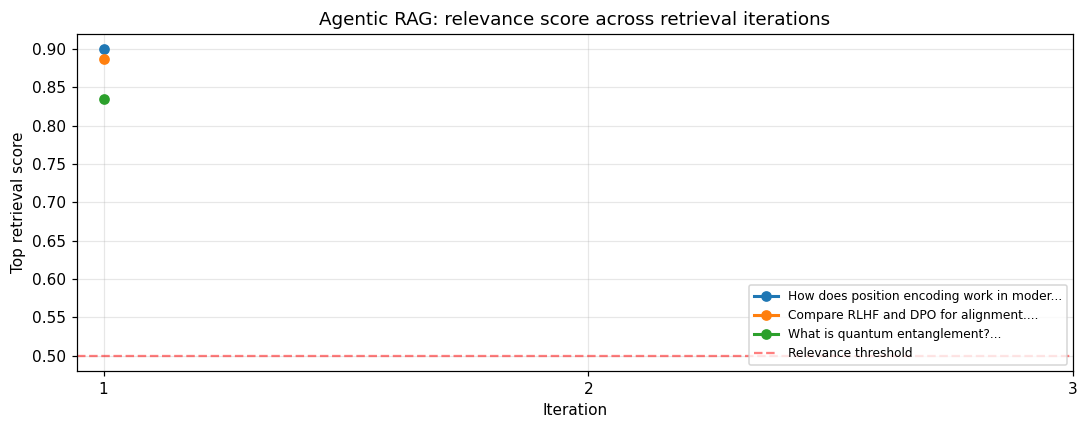

In [11]:
# Demo 8: Agentic RAG - iterative retrieval with query reformulation

@dataclass
class RAGTrace:
    # Trace of an agentic RAG session.
    query: str
    iterations: list[dict] = field(default_factory=list)
    final_answer: str = ""
    total_passages_retrieved: int = 0

def agentic_rag(
    query: str,
    index: VectorIndex,
    model,
    tokenizer,
    max_iterations: int = 3,
    relevance_threshold: float = 0.5,
    top_k: int = 3,
) -> RAGTrace:
    trace = RAGTrace(query=query)
    accumulated_passages = []
    current_query = query

    for iteration in range(max_iterations):
        # Retrieve
        q_emb = embed_texts([current_query], model, tokenizer)
        results = index.search(q_emb[0], top_k=top_k)

        # Check relevance
        top_score = results[0][1] if results else 0.0
        new_passages = [
            (score, meta["text"])
            for _, score, meta in results
            if meta["text"] not in [p[1] for p in accumulated_passages]
        ]

        step = {
            "iteration": iteration + 1,
            "search_query": current_query,
            "top_score": top_score,
            "new_passages": len(new_passages),
            "action": "",
        }

        accumulated_passages.extend(new_passages)
        trace.total_passages_retrieved += len(new_passages)

        if top_score >= relevance_threshold and len(accumulated_passages) >= 2:
            step["action"] = "GENERATE - sufficient evidence"
            trace.iterations.append(step)
            break
        elif iteration < max_iterations - 1:
            # Reformulate: append "details about" to narrow the query
            reformulations = [
                f"{query} technical details",
                f"{query} mechanism and implementation",
                f"explain {query} step by step",
            ]
            current_query = reformulations[min(iteration, len(reformulations) - 1)]
            step["action"] = f"REFORMULATE → '{current_query}'"
            trace.iterations.append(step)
        else:
            step["action"] = "GENERATE - max iterations reached"
            trace.iterations.append(step)

    # Generate from accumulated passages
    context = "\n\n".join(
        f"[{i+1}] {p[1]}" for i, p in enumerate(accumulated_passages[:5])
    )
    prompt = (
        f"Based on the following passages, answer the question.\n\n"
        f"{context}\n\n"
        f"Question: {query}\nAnswer:"
    )
    trace.final_answer = generate_text(model, tokenizer, prompt, max_new_tokens=80).strip()
    return trace


# Run agentic RAG on test queries
agentic_queries = [
    "How does position encoding work in modern transformers?",
    "Compare RLHF and DPO for alignment.",
    "What is quantum entanglement?",  # Out-of-domain
]

for q in agentic_queries:
    trace = agentic_rag(q, index, model, tokenizer)
    print(f"\n{'='*70}")
    print(f"Query: {trace.query}")
    print(f"Iterations: {len(trace.iterations)}  |  Total passages: {trace.total_passages_retrieved}")
    for step in trace.iterations:
        print(f"  [{step['iteration']}] top_score={step['top_score']:.4f}  "
              f"new={step['new_passages']}  → {step['action']}")
    print(f"Answer: {trace.final_answer[:150]}")

# Visualise iteration traces
fig, ax = plt.subplots(figsize=(10, 4))
for i, q in enumerate(agentic_queries):
    trace = agentic_rag(q, index, model, tokenizer)
    scores = [s["top_score"] for s in trace.iterations]
    ax.plot(range(1, len(scores) + 1), scores, "o-", label=q[:40] + "...", linewidth=2)

ax.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Relevance threshold")
ax.set_xlabel("Iteration")
ax.set_ylabel("Top retrieval score")
ax.set_title("Agentic RAG: relevance score across retrieval iterations")
ax.legend(fontsize=8, loc="lower right")
ax.set_xticks(range(1, 4))
plt.tight_layout()
plt.show()


# Diagnostics, Limitations, and Open Problems

## RAG Failure Modes

| Failure | Root Cause | Mitigation |
|---------|-----------|------------|
| **Retrieval miss** | Relevant passage not in top-$K$ | Increase $K$, improve embeddings, hybrid search |
| **Retrieval-induced hallucination** | Model fabricates from irrelevant retrieved context | Better chunking, reranking, stronger prompt instructions |
| **Lost in the middle** | Model ignores passages in the middle of the context | Place most relevant passages first and last |
| **Stale index** | Knowledge base not updated after source changes | Incremental indexing, TTL-based refresh |
| **Embedding drift** | Embedding model updated but index not re-embedded | Version-pin embedding model, re-index on model change |
| **Over-retrieval** | Too many passages dilute signal, waste context tokens | Reranking, adaptive $K$ selection |

## Open Problems (as of April 2026)

1. **Faithful attribution**: reliably tracing each claim in the response to a specific source passage.
2. **Long-document RAG**: chunking strategies that preserve discourse structure across 100k+ token documents.
3. **Multimodal RAG**: retrieving and reasoning over images, tables, and code alongside text.
4. **Freshness vs. cost**: incremental indexing strategies that keep the index current without full re-embedding.
5. **Evaluation at scale**: automated metrics that correlate with human judgements of RAG quality.


# Reproducibility

This notebook requires **PyTorch** and **Hugging Face Transformers** plus **scikit-learn** for TF-IDF. The first run downloads SmolLM2-135M base model weights (~270 MB). No API keys or GPU are required: all inference runs on CPU.

**To export:**

```bash
python scripts/export_notebook.py --notebook rag_how_they_work.ipynb --output-dir exports
```

**Companion notebooks:** [How LLMs Work](llms_how_they_work.ipynb) covers the architecture and inference pipeline. [Prompt Engineering](prompt_engineering_how_they_work.ipynb) covers prompt conditioning, in-context learning, chain-of-thought, and reasoning-time compute. [How Agents Work](agents_how_they_work.ipynb) covers agent architectures, tool use, orchestration, memory, security, evaluation, and a capstone implementation.


In [12]:
# Environment report
import platform

print(f"Platform:      {platform.platform()}")
print(f"Python:        {sys.version}")
print(f"NumPy:         {np.__version__}")
print(f"Pandas:        {pd.__version__}")
print(f"Matplotlib:    {plt.matplotlib.__version__}")
print(f"Seaborn:       {sns.__version__}")
print(f"PyTorch:       {torch.__version__}")
print(f"Transformers:  {_tf.__version__}")


Platform:      Windows-10-10.0.26200-SP0
Python:        3.11.14 | packaged by conda-forge | (main, Jan 26 2026, 23:39:55) [MSC v.1944 64 bit (AMD64)]
NumPy:         2.1.3
Pandas:        3.0.0
Matplotlib:    3.10.8
Seaborn:       0.13.2
PyTorch:       2.11.0+cpu
Transformers:  5.6.2


# References

1. Lewis, P., Perez, E., Piktus, A., et al. (2020). *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*. [arXiv:2005.11401](https://arxiv.org/abs/2005.11401)
2. Karpukhin, V., Oğuz, B., Min, S., et al. (2020). *Dense Passage Retrieval for Open-Domain Question Answering* (DPR). [arXiv:2004.04906](https://arxiv.org/abs/2004.04906)
3. Gao, L., Ma, X., Lin, J., Callan, J. (2022). *Precise Zero-Shot Dense Retrieval without Relevance Labels* (HyDE). [arXiv:2212.10496](https://arxiv.org/abs/2212.10496)
4. Johnson, J., Douze, M., Jégou, H. (2019). *Billion-scale similarity search with GPUs* (FAISS). [arXiv:1702.08734](https://arxiv.org/abs/1702.08734)
5. Malkov, Y.A. & Yashunin, D.A. (2020). *Efficient and Robust Approximate Nearest Neighbor Using Hierarchical Navigable Small World Graphs* (HNSW). [arXiv:1603.09320](https://arxiv.org/abs/1603.09320)
6. Guu, K., Lee, K., Tung, Z., Pasupat, P., Chang, M.-W. (2020). *REALM: Retrieval-Augmented Language Model Pre-Training*. [arXiv:2002.08909](https://arxiv.org/abs/2002.08909)
7. Izacard, G. & Grave, E. (2021). *Leveraging Passage Retrieval with Generative Models for Open Domain Question Answering* (FiD). [arXiv:2007.01282](https://arxiv.org/abs/2007.01282)
8. Glass, M., Rossiello, G., Chowdhury, M.F.M., et al. (2022). *Re2G: Retrieve, Rerank, Generate*. [arXiv:2207.06300](https://arxiv.org/abs/2207.06300)
9. Es, S., James, J., Espinosa-Anke, L., Schockaert, S. (2024). *RAGAs: Automated Evaluation of Retrieval Augmented Generation*. [arXiv:2309.15217](https://arxiv.org/abs/2309.15217)
10. Borgeaud, S., Mensch, A., Hoffmann, J., et al. (2022). *Improving Language Models by Retrieving from Trillions of Tokens* (RETRO). [arXiv:2112.04426](https://arxiv.org/abs/2112.04426)
11. Allal, L.B., Lozhkov, A., Penedo, G., et al. (2025). *SmolLM2: When Smol Goes Big*. [arXiv:2502.02737](https://arxiv.org/abs/2502.02737)
12. Robertson, S. & Zaragoza, H. (2009). *The Probabilistic Relevance Framework: BM25 and Beyond*. Foundations and Trends in IR.
13. Khattab, O. & Zaharia, M. (2020). *ColBERT: Efficient and Effective Passage Search via Contextualized Late Interaction over BERT*. [arXiv:2004.12832](https://arxiv.org/abs/2004.12832)
14. Santhanam, K., Khattab, O., Saad-Falcon, J., et al. (2022). *ColBERTv2: Effective and Efficient Retrieval via Lightweight Late Interaction*. [arXiv:2112.01488](https://arxiv.org/abs/2112.01488)
15. Asai, A., Wu, Z., Wang, Y., Sil, A., Hajishirzi, H. (2023). *Self-RAG: Learning to Retrieve, Generate, and Critique through Self-Reflection*. [arXiv:2310.11511](https://arxiv.org/abs/2310.11511)
16. Yan, S.-Q., Gu, J.-C., Zhu, Y., Ling, Z.-H. (2024). *Corrective Retrieval Augmented Generation* (CRAG). [arXiv:2401.15884](https://arxiv.org/abs/2401.15884)
17. Edge, D., Trinh, H., Cheng, N., et al. (2024). *From Local to Global: A Graph RAG Approach to Query-Focused Summarization*. [arXiv:2404.16130](https://arxiv.org/abs/2404.16130)
18. Chen, J., Xiao, S., Zhang, P., et al. (2024). *BGE M3-Embedding: Multi-Lingual, Multi-Functionality, Multi-Granularity Text Embeddings Through Self-Knowledge Distillation*. [arXiv:2402.03216](https://arxiv.org/abs/2402.03216)
19. Faysse, M., Sibille, H., Wu, T., et al. (2024). *ColPali: Efficient Document Retrieval with Vision Language Models*. [arXiv:2407.01449](https://arxiv.org/abs/2407.01449)
20. Liu, N.F., Lin, K., Hewitt, J., et al. (2023). *Lost in the Middle: How Language Models Use Long Contexts*. [arXiv:2307.03172](https://arxiv.org/abs/2307.03172)


GitHub repository: [https://github.com/adamd1985/quant_research/blob/main/rag_how_they_work.ipynb](https://github.com/adamd1985/quant_research/blob/main/rag_how_they_work.ipynb)

Kaggle notebook available [here](https://www.kaggle.com/code/addarm/rag-how-they-work)

# Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.
